In [1]:
import os
import gc
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
folder_path = r'D:\clone\merged'

In [2]:
def load_and_aggregate_clouds(tcc_f, lcc_f, hcc_f):
    def preprocess(ds):
        if 'valid_time' in ds.coords: ds = ds.rename({'valid_time': 'time'})
        if 'expver' in ds.dims: ds = ds.mean(dim='expver')
        return ds.sortby('time')

    files = [tcc_f, lcc_f, hcc_f]
    keys = ['tcc', 'lcc', 'hcc']
    df_daily = pd.DataFrame()

    for f, k in zip(files, keys):
        ds = preprocess(xr.open_dataset(os.path.join(folder_path, f)))
        var = list(ds.data_vars)[0]
        data = ds[var].mean(dim=['latitude', 'longitude']).resample(time='1D').mean().compute()
        df_daily[k] = data.values
        if k == 'tcc': df_daily.index = data.time.values
        ds.close(); gc.collect()

    df_daily['mcc'] = (df_daily['tcc'] - np.maximum(df_daily['lcc'], df_daily['hcc'])).clip(0, 1)
    df_daily['lhd'] = df_daily['lcc'] - df_daily['hcc']
    
    df_monthly = df_daily.resample('ME').mean()
    df_yearly = df_daily.resample('YS').mean()
    
    clim = df_monthly.groupby(df_monthly.index.month).mean()
    
    df_monthly['month'] = df_monthly.index.month
    df_monthly['year'] = df_monthly.index.year
    
    for k in ['tcc', 'lcc', 'hcc', 'lhd']:
        df_monthly[f'{k}_anom'] = df_monthly[k] - df_monthly['month'].map(clim[k])

    return df_daily, df_monthly, df_yearly, clim

In [3]:
t_f = 'total_cloud_cover_merged.nc'
l_f = 'low_cloud_cover_merged.nc'
h_f = 'high_cloud_cover_merged.nc'

df_daily, df_monthly, df_yearly, clim = load_and_aggregate_clouds(t_f, l_f, h_f)
df_monthly.head()

,tcc,lcc,hcc,mcc,lhd,month,year,tcc_anom,lcc_anom,hcc_anom,lhd_anom
1980-01-31,0.441079,0.277234,0.140960,0.158685,0.136274,1,1980,-0.112190,-0.029944,-0.118253,0.088309
1980-02-29,0.497136,0.329043,0.118211,0.164846,0.210833,2,1980,-0.001387,0.045247,-0.091693,0.136940
1980-03-31,0.416060,0.204269,0.202049,0.155396,0.002220,3,1980,-0.084483,-0.039122,-0.064673,0.025551
1980-04-30,0.617294,0.198926,0.507306,0.109610,-0.308380,4,1980,0.041571,-0.008614,0.085269,-0.093883
1980-05-31,0.737021,0.244636,0.654058,0.082962,-0.409422,5,1980,-0.022566,0.040979,-0.028835,0.069815


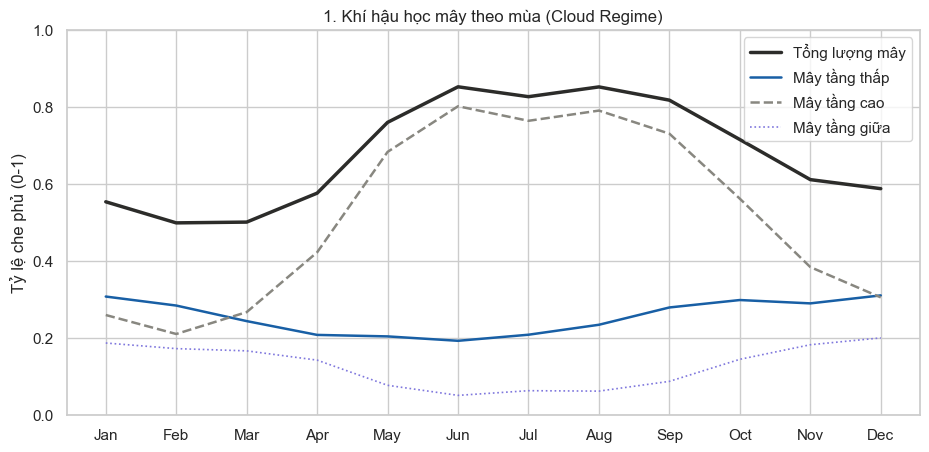

In [4]:
plt.figure(figsize=(11, 5))
months = np.arange(1, 13)
plt.plot(months, clim['tcc'], color="#2C2C2A", lw=2.5, label="Tổng lượng mây")
plt.plot(months, clim['lcc'], color="#185FA5", lw=1.8, label="Mây tầng thấp")
plt.plot(months, clim['hcc'], color="#888780", lw=1.8, ls="--", label="Mây tầng cao")
plt.plot(months, clim['mcc'], color="#7F77DD", lw=1.2, ls=":", label="Mây tầng giữa")
plt.xticks(months, ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.title("1. Khí hậu học mây theo mùa (Cloud Regime)")
plt.ylabel("Tỷ lệ che phủ (0-1)")
plt.ylim(0, 1)
plt.legend()
plt.show()

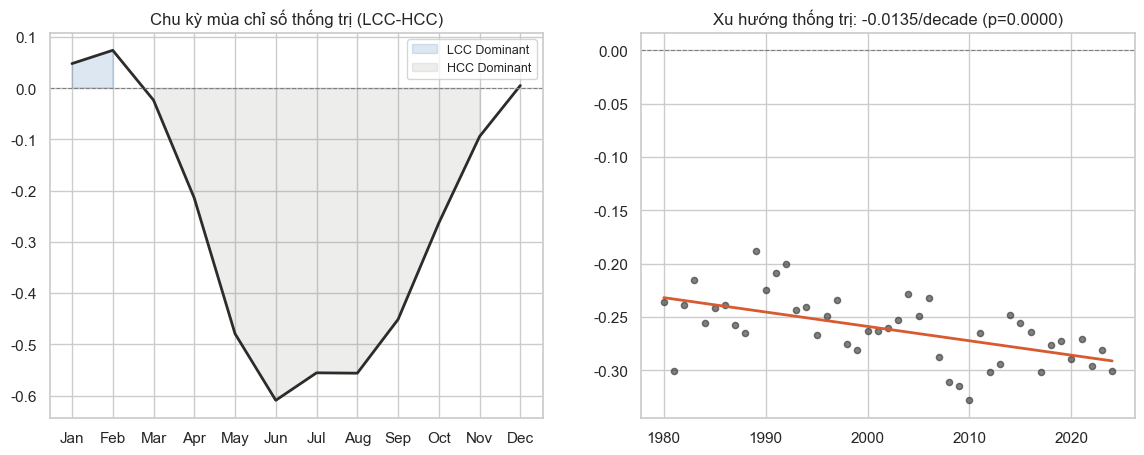

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
months = np.arange(1, 13)

axes[0].plot(months, clim['lhd'], color="#2C2C2A", lw=2)
axes[0].axhline(0, color="gray", ls="--", lw=0.8)
axes[0].fill_between(months, clim['lhd'], 0, where=clim['lhd'] > 0, alpha=0.15, color="#185FA5", label="LCC Dominant")
axes[0].fill_between(months, clim['lhd'], 0, where=clim['lhd'] < 0, alpha=0.15, color="#888780", label="HCC Dominant")
axes[0].set_xticks(months)
axes[0].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
axes[0].set_title("Chu kỳ mùa chỉ số thống trị (LCC-HCC)")
axes[0].legend(fontsize=9)

y_lhd = df_yearly['lhd'].values
x_years = df_yearly.index.year.values
slope, intercept, r, p, _ = stats.linregress(x_years, y_lhd)
axes[1].scatter(x_years, y_lhd, s=20, color="#2C2C2A", alpha=0.6)
axes[1].plot(x_years, intercept + slope * x_years, color="#D85A30", lw=2)
axes[1].axhline(0, color="gray", ls="--", lw=0.8)
axes[1].set_title(f"Xu hướng thống trị: {slope*10:+.4f}/decade (p={p:.4f})")
plt.show()

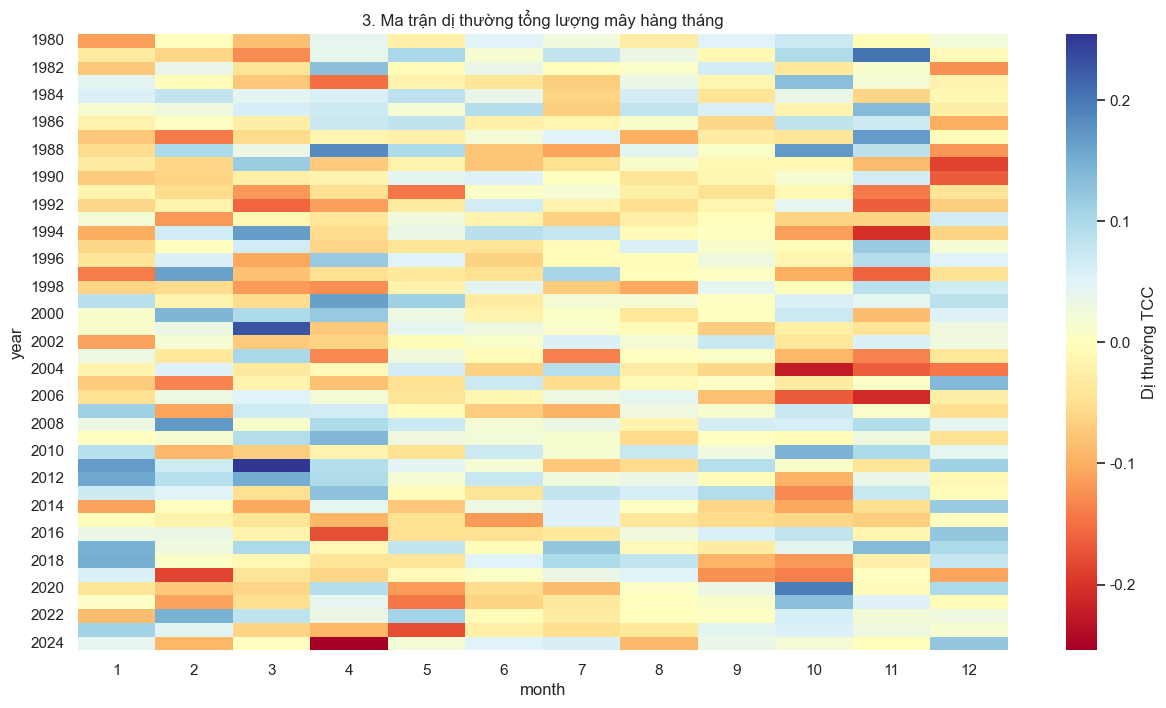

In [6]:
pivot = df_monthly.pivot(index='year', columns='month', values='tcc_anom')
plt.figure(figsize=(15, 8))
sns.heatmap(pivot, cmap="RdYlBu", center=0, cbar_kws={'label': 'Dị thường TCC'})
plt.title("3. Ma trận dị thường tổng lượng mây hàng tháng")
plt.show()

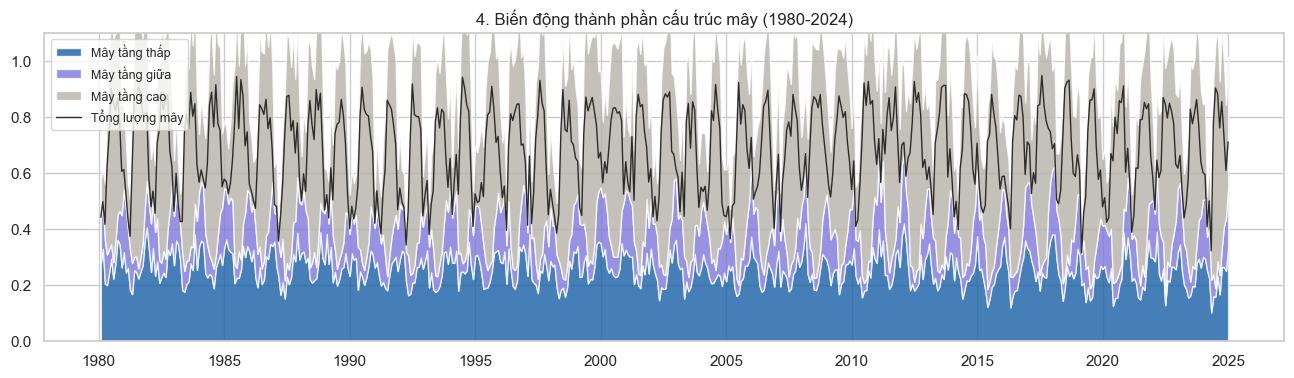

In [7]:
plt.figure(figsize=(16, 4))
plt.stackplot(df_monthly.index, 
              df_monthly['lcc'], df_monthly['mcc'], df_monthly['hcc'], 
              labels=["Mây tầng thấp", "Mây tầng giữa", "Mây tầng cao"], 
              colors=["#185FA5", "#7F77DD", "#B4B2A9"], alpha=0.8)
plt.plot(df_monthly.index, df_monthly['tcc'], color="#2C2C2A", lw=1, label="Tổng lượng mây")
plt.ylim(0, 1.1)
plt.title("4. Biến động thành phần cấu trúc mây (1980-2024)")
plt.legend(loc="upper left", fontsize=9)
plt.show()

In [8]:
try:
    df_rad = pd.read_csv(os.path.join(folder_path, 'derived_radiation_daily.csv'), index_col=0, parse_dates=True)
    df_val = pd.concat([df_daily, df_rad['ssr']], axis=1).dropna()
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    for ax, cvar, title, color in zip(axes, ['tcc', 'lcc', 'hcc'], 
                                      ['Total Cloud', 'Low Cloud', 'High Cloud'],
                                      ['#2C2C2A', '#185FA5', '#888780']):
        ax.scatter(df_val[cvar], df_val['ssr'], s=2, alpha=0.2, color=color)
        sl, ic, r, p, _ = stats.linregress(df_val[cvar], df_val['ssr'])
        ax.plot([0, 1], [ic, ic + sl], color='red', lw=2)
        ax.set_title(f"{title}\nslope={sl:.1f}")
        ax.set_xlabel("Fraction")
    axes[0].set_ylabel("Surface Solar Radiation (W/m²)")
    plt.suptitle("5. Kiểm định vật lý: Độ mây vs Bức xạ mặt trời")
    plt.show()
except:
    print("Cần dữ liệu bức xạ từ NB 09 để vẽ biểu đồ 5")

Cần dữ liệu bức xạ từ NB 09 để vẽ biểu đồ 5


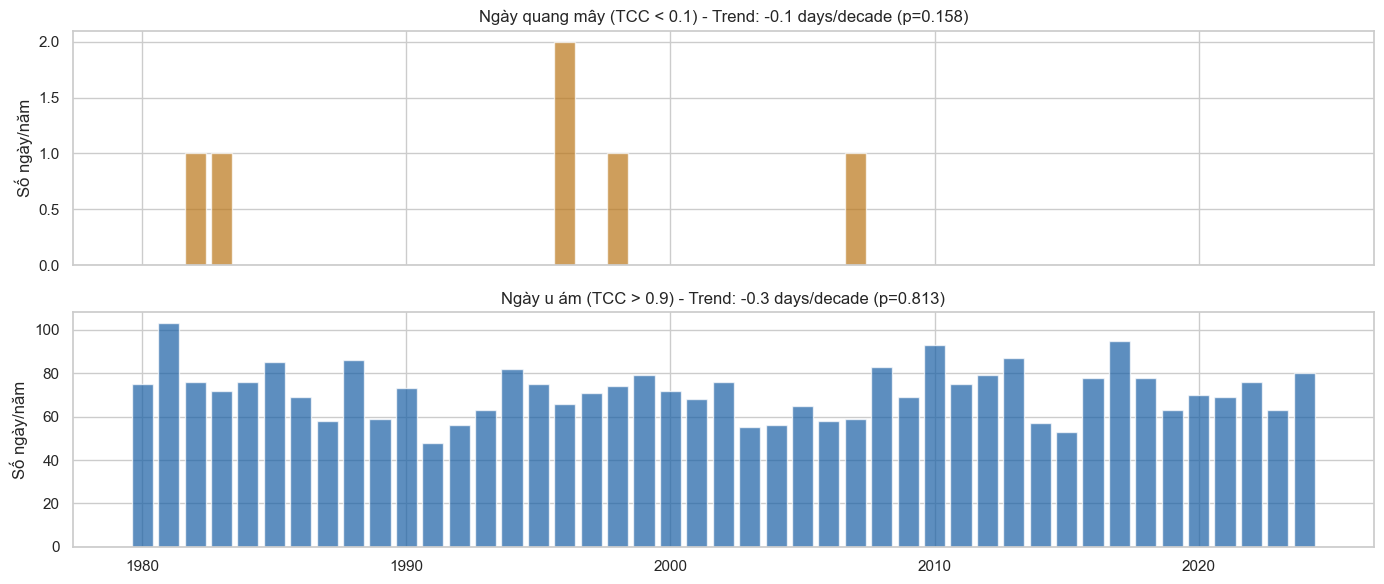

In [14]:
overcast = (df_daily['tcc'] > 0.9).resample("1YE").sum()
clear = (df_daily['tcc'] < 0.1).resample("1YE").sum()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax, data, label, color in zip(axes, [clear, overcast], 
                                  ["Ngày quang mây (TCC < 0.1)", "Ngày u ám (TCC > 0.9)"], 
                                  ["#BA7517", "#185FA5"]):
    ax.bar(data.index.year, data.values, color=color, alpha=0.7)
    sl, _, _, p, _ = stats.linregress(data.index.year, data.values)
    ax.set_title(f"{label} - Trend: {sl*10:+.1f} days/decade (p={p:.3f})")
    ax.set_ylabel("Số ngày/năm")
plt.tight_layout()
plt.show()

In [16]:
try:
    ds_cape = xr.open_dataset(os.path.join(folder_path, 'convective_available_potential_energy_merged.nc'))
    if 'expver' in ds_cape.dims: ds_cape = ds_cape.mean(dim='expver')
    if 'valid_time' in ds_cape.coords: ds_cape = ds_cape.rename({'valid_time': 'time'})
    cape = ds_cape['cape'].mean(dim=['latitude', 'longitude']).resample(time='1ME').mean().compute()
    
    df_cape = pd.DataFrame({
        'anom_tcc': df_monthly['tcc_anom'].values,
        'anom_hcc': df_monthly['hcc_anom'].values,
        'anom_cape': (cape - cape.groupby('time.month').mean('time')).values,
        'month': df_monthly['month'].values
    }).dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, cvar, title in zip(axes, ['anom_tcc', 'anom_hcc'], ['Total Cloud Anomaly', 'High Cloud Anomaly']):
        sc = ax.scatter(df_cape['anom_cape'], df_cape[cvar], c=df_cape['month'], cmap="twilight", s=10, alpha=0.6)
        sl, ic, r, p, _ = stats.linregress(df_cape['anom_cape'], df_cape[cvar])
        ax.plot(df_cape['anom_cape'], ic + sl*df_cape['anom_cape'], color='black')
        ax.set_title(f"{title}\nslope={sl:.5f}, r²={r**2:.3f}")
        ax.set_xlabel("CAPE Anomaly (J/kg)")
    plt.show()
    ds_cape.close()
except:
    print("Cần file CAPE để vẽ biểu đồ 7")

Cần file CAPE để vẽ biểu đồ 7


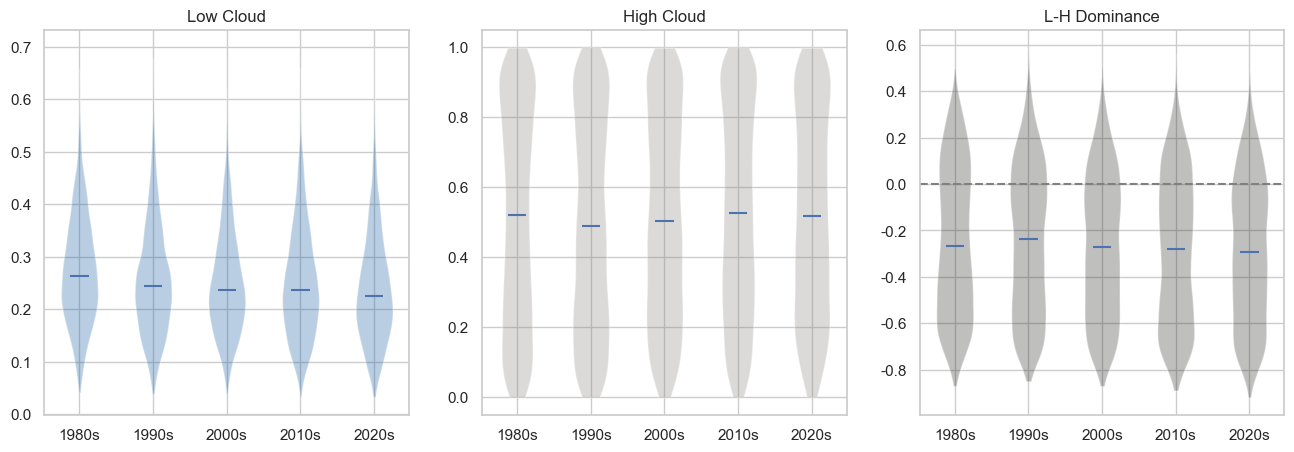

In [17]:
decades = {"1980s": slice("1980","1989"), "1990s": slice("1990","1999"), "2000s": slice("2000","2009"), "2010s": slice("2010","2019"), "2020s": slice("2020","2024")}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (var, label, color) in zip(axes, [('lcc', 'Low Cloud', '#185FA5'), ('hcc', 'High Cloud', '#888780'), ('lhd', 'L-H Dominance', '#2C2C2A')]):
    data_list = []
    for d_label, sl in decades.items():
        vals = df_daily.loc[sl, var].values
        data_list.append(vals[~np.isnan(vals)])
    parts = ax.violinplot(data_list, showmedians=True, showextrema=False)
    for pc in parts['bodies']: pc.set_facecolor(color)
    ax.set_xticks(range(1, 6))
    ax.set_xticklabels(decades.keys())
    ax.set_title(label)
    if var == 'lhd': ax.axhline(0, color='gray', ls='--')
plt.show()

In [18]:
df_daily[['lhd', 'mcc']].to_csv(os.path.join(folder_path, 'derived_clouds_daily.csv'))